# MeteoSwiss reference meteorology — Lägern (LAE), 2004-2025

***
**Site**: CH-LAE &nbsp;&nbsp;|&nbsp;&nbsp; **Reference station**: Lägern (LAE), MeteoSwiss
**Product**: 30MIN 2004-2025 (aggregated from published 10-min values)
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

> **Source: MeteoSwiss.** These data are free to use, but the source must be cited whenever they
> are reproduced or redistributed. Keep this attribution with any figure or derived product.

## ℹ️ About this notebook
Downloads the full 10-minute record of the MeteoSwiss SMN station **Lägern (`lae`)** from the
open-data STAC API, aggregates it to **30MIN**, and writes one wide reference product.

This notebook **does not touch the InfluxDB database** and screens nothing. It only fetches an
independent reference and puts it on our time axis.

**Why LAE.** It is the closest MeteoSwiss station to the tower — **2.5 km** away on the same
ridge, at **845 m**, which is above the tower top (689 m base + 47 m). Unlike the NABEL sensors,
which stop in 2018, it covers the whole record. It is a full automatic weather station, so one
download yields references for `TA`, `RH`, `PA` and `SW_IN` at once.

**What LAE does *not* measure.** Checked against the data, not the station description:

| Variable | Parameter | Status |
|---|---|---|
| Precipitation | `rre150z0` | **empty in every record** — this is why the reference gauge is OED |
| Incoming longwave | `oli000z0` | **empty in every record** — notebook `06` (`LW_IN`) gets no reference here |
| Outgoing longwave / reflected shortwave | `olo000z0`, `osr000z0` | empty |
| Soil temperature | `tso005s0`, `tso010s0`, `tso020s0` | empty |

**Coverage.** The 10-min record begins **2004-02-01**, so **January 2004 has no LAE reference**.
From February 2004 on, every exported parameter is ≥99% complete in every year, except diffuse
radiation (`ods000z0`), which only starts in 2011.

## ⏱️ Timestamp convention (important)
MeteoSwiss publishes all reference timestamps in **UTC**. For the 10-min files,
`reference_timestamp` marks the **end** of the interval: a record at `t` covers `(t-10min, t]`.
This matches our database's `TIMESTAMP_END`, so the aggregated product is binned end-labelled and
then shifted by `TIMEZONE_OFFSET_TO_UTC_HOURS` into local time.

This was **verified empirically**, not taken on trust — see *Cross-check against the published
hourly file* below.

**Instantaneous vs mean.** The parameter descriptions distinguish two kinds of 10-min value, and
the distinction survives into the 30MIN product:

- `gre000z0`, `ods000z0`, `dkl010z0` are **ten-minute means**. Averaging three of them gives a
  true half-hourly mean.
- `tre200s0`, `ure200s0`, `tde200s0`, `pva200s0`, `prestas0` are **current values** — instantaneous
  spot readings. Averaging three gives a three-sample estimate of the half-hourly mean, not the
  mean itself. For smoothly varying quantities the difference is small, but it is not zero, and it
  is the honest description of what this product contains.

## ✏️ Settings

In [1]:
# --- Reference station ---
STAC_COLLECTION = 'ch.meteoschweiz.ogd-smn'  # full automatic weather stations
STAC_STATION = 'lae'                         # Lägern, 47.481933 N / 8.397222 E, 845 m

# --- Period ---
START = '2004-01-01'  # included (data actually begin 2004-02-01)
STOP = '2026-01-01'   # not included

# --- Time axis ---
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # UTC+01:00 (CET), same value the meteo notebooks use
TARGET_FREQ = '30min'
RECORDS_PER_BIN = 3  # three 10-min records make one complete 30MIN bin

# --- Parameters to export: shortname -> (output column, aggregation) ---
# 'mean' for state variables and 10-min means, 'sum' for durations, 'max' for gusts,
# 'circmean' for wind direction (see the helper: degrees cannot be averaged linearly).
PARAMS = {
    'tre200s0': ('TA_LAE_MS', 'mean'),          # air temperature 2 m [°C]
    'ure200s0': ('RH_LAE_MS', 'mean'),          # relative humidity 2 m [%]
    'tde200s0': ('TDEW_LAE_MS', 'mean'),        # dew point 2 m [°C]
    'pva200s0': ('VP_LAE_MS', 'mean'),          # vapour pressure 2 m [hPa]
    'prestas0': ('PA_LAE_MS', 'mean'),          # pressure at station altitude, QFE [hPa]
    'gre000z0': ('SW_IN_LAE_MS', 'mean'),       # global radiation [W m-2]
    'ods000z0': ('SW_IN_DIFF_LAE_MS', 'mean'),  # diffuse radiation [W m-2], from 2011
    'sre000z0': ('SUNDUR_LAE_MS', 'sum'),       # sunshine duration [min]
    'fve010z0': ('WS_LAE_MS', 'mean'),          # wind speed, vectorial 10-min mean [m s-1]
    'fkl010z1': ('WS_GUST_LAE_MS', 'max'),      # gust peak, 1 s maximum [m s-1]
    'dkl010z0': ('WD_LAE_MS', 'circmean'),      # wind direction, 10-min mean [°]
}

# --- Output ---
# Mirrors this notebook's own path under the external data folder, per the repo
# convention: a data file carries the same relative path as the code that produces it.
OUTDIR = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
          r'\workflow\10_METEO\10_REFERENCE')
OUTNAME = 'MeteoSwiss_LAE_30MIN'
EXPORT_FORMATS = ('parquet', 'csv')  # parquet keeps dtypes/index; csv is for eyeballing and sharing

### Imports

In [2]:
import io
import json
import urllib.request
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 1000)
print(f"Last run: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f'pandas v{pd.__version__}')

Last run: 2026-07-20 20:59:47
pandas v3.0.3


## 🔧 Helpers

In [3]:
STAC_ITEM_URL = f'https://data.geo.admin.ch/api/stac/v1/collections/{STAC_COLLECTION}/items/{STAC_STATION}'


def stac_assets(url: str) -> dict:
    """Return {filename: href} for a STAC item. Raises if the item has no assets."""
    with urllib.request.urlopen(url) as r:
        item = json.load(r)
    assets = {k: v['href'] for k, v in item.get('assets', {}).items()}
    if not assets:
        raise ValueError(f'STAC item {url} exposes no assets - wrong collection or station?')
    return assets


def read_ms_csv(href: str, params: list) -> pd.DataFrame:
    """Read one MeteoSwiss CSV and return *params* as a UTC-indexed, sorted DataFrame."""
    with urllib.request.urlopen(href) as r:
        df = pd.read_csv(io.BytesIO(r.read()), sep=';')
    missing = [p for p in params if p not in df.columns]
    if missing:
        raise ValueError(f'{missing} not in {href} (has: {list(df.columns)})')
    df['TIMESTAMP'] = pd.to_datetime(df['reference_timestamp'], format='%d.%m.%Y %H:%M')
    return df.set_index('TIMESTAMP')[params].sort_index()


def circular_mean(deg: pd.Series, freq: str) -> pd.Series:
    """Resample a direction in degrees by averaging on the unit circle.

    A linear mean is wrong for directions: 350° and 10° average to 180°
    (due south) instead of 0° (due north). Averaging the sine and cosine
    components and taking the arctangent gives the right answer.
    """
    rad = np.deg2rad(deg)
    res_s = np.sin(rad).resample(freq, label='right', closed='right').mean()
    res_c = np.cos(rad).resample(freq, label='right', closed='right').mean()
    return (np.rad2deg(np.arctan2(res_s, res_c)) % 360).where(res_s.notna())

### Negative control
A helper that can silently do nothing gets a cell that feeds it bad input and asserts it raises.

In [4]:
# Wrong collection: LAE is a full weather station, not a precip-only station.
try:
    stac_assets(f'https://data.geo.admin.ch/api/stac/v1/collections/'
                f'ch.meteoschweiz.ogd-smn-precip/items/{STAC_STATION}')
except Exception as e:
    print(f'OK, raised as expected: {type(e).__name__}')
else:
    raise AssertionError('expected a failure for the precip-only collection, got assets')

# Wrong parameter name must raise rather than return an empty frame.
try:
    read_ms_csv(stac_assets(STAC_ITEM_URL)['ogd-smn_lae_t_historical_2010-2019.csv'], ['nosuchparam'])
except ValueError as e:
    print(f'OK, raised as expected: {str(e)[:60]}...')
else:
    raise AssertionError('expected a ValueError for an unknown parameter')

# circular_mean must not return the linear mean across the 0/360 wrap.
_idx = pd.date_range('2020-01-01 00:00', periods=6, freq='10min')
_test = pd.Series([350.0, 10.0, 350.0, 10.0, 350.0, 10.0], index=_idx)
_got = circular_mean(_test, '30min').iloc[0]
assert _got > 340 or _got < 20, f'circular mean across the wrap is broken: got {_got}'
print(f'OK, circular mean of [350, 10, 350] = {_got:.1f}° (a linear mean would give 236.7°)')

OK, raised as expected: HTTPError


OK, raised as expected: ['nosuchparam'] not in https://data.geo.admin.ch/ch.meteosch...
OK, circular mean of [350, 10, 350] = 350.0° (a linear mean would give 236.7°)


## ⬇️ Available files

In [5]:
assets = stac_assets(STAC_ITEM_URL)
print(f'Station: {STAC_STATION.upper()}  |  collection: {STAC_COLLECTION}')
for k in sorted(assets):
    print(f'  {k}')

Station: LAE  |  collection: ch.meteoschweiz.ogd-smn
  ogd-smn_lae_d_historical.csv
  ogd-smn_lae_d_recent.csv
  ogd-smn_lae_h_historical_1980-1989.csv
  ogd-smn_lae_h_historical_1990-1999.csv
  ogd-smn_lae_h_historical_2000-2009.csv
  ogd-smn_lae_h_historical_2010-2019.csv
  ogd-smn_lae_h_historical_2020-2029.csv
  ogd-smn_lae_h_now.csv
  ogd-smn_lae_h_recent.csv
  ogd-smn_lae_m.csv
  ogd-smn_lae_t_historical_2000-2009.csv
  ogd-smn_lae_t_historical_2010-2019.csv
  ogd-smn_lae_t_historical_2020-2029.csv
  ogd-smn_lae_t_now.csv
  ogd-smn_lae_t_recent.csv
  ogd-smn_lae_y.csv


## 📥 Download the 10-min record
The three `_t_historical_` files already cover 2004-2025; `_t_recent` holds the current year and is
deliberately **not** used, so re-running this notebook reproduces the same product.

In [6]:
hires_files = sorted(k for k in assets if '_t_historical_' in k)
print(f'Concatenating: {hires_files}')

raw = pd.concat([read_ms_csv(assets[k], list(PARAMS)) for k in hires_files]).sort_index()
raw = raw[~raw.index.duplicated(keep='first')]
raw = raw.loc[START:STOP]
print(f'10MIN raw: {len(raw):,} records, {raw.index[0]} -> {raw.index[-1]} (UTC)')

raw = raw.reindex(pd.date_range(raw.index[0], raw.index[-1], freq='10min'))
print(f'On gapless grid: {len(raw):,} records')
print(f'\nMissing per parameter:')
for short, (name, _) in PARAMS.items():
    print(f'  {short}  {name:<20s} {raw[short].isna().mean() * 100:6.2f}%')

Concatenating: ['ogd-smn_lae_t_historical_2000-2009.csv', 'ogd-smn_lae_t_historical_2010-2019.csv', 'ogd-smn_lae_t_historical_2020-2029.csv']


10MIN raw: 1,152,553 records, 2004-02-01 00:00:00 -> 2025-12-31 23:50:00 (UTC)
On gapless grid: 1,152,720 records

Missing per parameter:
  tre200s0  TA_LAE_MS              0.07%
  ure200s0  RH_LAE_MS              0.08%
  tde200s0  TDEW_LAE_MS            0.08%
  pva200s0  VP_LAE_MS              0.08%
  prestas0  PA_LAE_MS              0.11%
  gre000z0  SW_IN_LAE_MS           0.03%
  ods000z0  SW_IN_DIFF_LAE_MS     30.58%
  sre000z0  SUNDUR_LAE_MS          0.04%
  fve010z0  WS_LAE_MS              0.63%
  fkl010z1  WS_GUST_LAE_MS         0.63%
  dkl010z0  WD_LAE_MS              0.10%


### Coverage per year
Proves the claim in *About this notebook* rather than asserting it.

In [7]:
_cov = raw.notna().groupby(raw.index.year).mean().mul(100).round(1)
_cov.columns = [PARAMS[c][0] for c in _cov.columns]
_cov

,TA_LAE_MS,RH_LAE_MS,TDEW_LAE_MS,VP_LAE_MS,PA_LAE_MS,SW_IN_LAE_MS,SW_IN_DIFF_LAE_MS,SUNDUR_LAE_MS,WS_LAE_MS,WS_GUST_LAE_MS,WD_LAE_MS
2004,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0
2005,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0
2006,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0
2007,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0
2008,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0
2009,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0
2010,100.0,100.0,100.0,100.0,100.0,100.0,23.6,100.0,100.0,100.0,100.0
2011,100.0,99.8,99.8,99.8,100.0,100.0,99.9,100.0,100.0,100.0,100.0
2012,99.6,99.6,99.6,99.6,99.6,99.5,99.3,99.3,99.7,99.7,99.7
2013,100.0,100.0,100.0,100.0,99.6,100.0,99.8,100.0,100.0,100.0,100.0


## ⏲️ Aggregate to 30MIN
One rule per parameter, from the `PARAMS` table. `N_RECORDS` counts the 10-min values behind each
bin so an incomplete bin can be told from a complete one downstream.

In [8]:
def aggregate(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    """Aggregate 10-min (end-labelled) values to *freq*, one rule per parameter."""
    res = df.resample(freq, label='right', closed='right')
    out = {}
    for short, (name, how) in PARAMS.items():
        if how == 'mean':
            out[name] = res[short].mean()
        elif how == 'sum':
            out[name] = res[short].sum(min_count=1)  # min_count: all-NaN stays NaN, not 0
        elif how == 'max':
            out[name] = res[short].max()
        elif how == 'circmean':
            out[name] = circular_mean(df[short], freq)
        else:
            raise ValueError(f'unknown aggregation {how!r} for {short}')
    out['N_RECORDS'] = res['tre200s0'].count()
    return pd.DataFrame(out)


lae30 = aggregate(raw, TARGET_FREQ)
print(f'{TARGET_FREQ}: {len(lae30):,} periods, {lae30.index[0]} -> {lae30.index[-1]} (UTC)')
_inc = lae30['N_RECORDS'] < RECORDS_PER_BIN
print(f'Incomplete bins (N_RECORDS < {RECORDS_PER_BIN}): {_inc.sum():,} ({_inc.mean() * 100:.3f}%)')
lae30.head()

30min: 384,241 periods, 2004-02-01 00:00:00 -> 2026-01-01 00:00:00 (UTC)
Incomplete bins (N_RECORDS < 3): 280 (0.073%)


,TA_LAE_MS,RH_LAE_MS,TDEW_LAE_MS,VP_LAE_MS,PA_LAE_MS,SW_IN_LAE_MS,SW_IN_DIFF_LAE_MS,SUNDUR_LAE_MS,WS_LAE_MS,WS_GUST_LAE_MS,WD_LAE_MS,N_RECORDS
2004-02-01 00:00:00,4.400000,81.200000,1.500000,6.800000,921.100000,0.0,NaN,0.0,10.400000,21.0,219.000000,1
2004-02-01 00:30:00,4.466667,80.700000,1.433333,6.800000,921.166667,2.0,NaN,0.0,11.500000,25.0,216.999898,3
2004-02-01 01:00:00,4.533333,80.633333,1.466667,6.800000,921.066667,2.0,NaN,0.0,12.233333,26.5,216.333296,3
2004-02-01 01:30:00,4.700000,80.333333,1.600000,6.900000,921.500000,2.0,NaN,0.0,11.100000,23.1,217.000000,3
2004-02-01 02:00:00,4.600000,80.733333,1.566667,6.833333,921.633333,2.0,NaN,0.0,11.966667,24.8,217.000000,3


### Guard: prove the binning
Picks one half-hour and shows the three 10-min records behind it, so the `(t-30min, t]` convention
is demonstrated on real numbers instead of asserted.

In [9]:
_probe = pd.Timestamp('2015-06-15 10:00')
_window = raw.loc[_probe - pd.Timedelta(minutes=20):_probe, ['tre200s0', 'gre000z0']]
print(f'10-min records feeding the bin labelled {_probe}:')
print(_window.to_string())
print(f'\nmean TA  = {_window["tre200s0"].mean():.4f}  '
      f'-> exported {lae30.loc[_probe, "TA_LAE_MS"]:.4f}')
print(f'mean SW  = {_window["gre000z0"].mean():.4f}  '
      f'-> exported {lae30.loc[_probe, "SW_IN_LAE_MS"]:.4f}')

assert np.isclose(_window['tre200s0'].mean(), lae30.loc[_probe, 'TA_LAE_MS'])
assert np.isclose(_window['gre000z0'].mean(), lae30.loc[_probe, 'SW_IN_LAE_MS'])
assert lae30.loc[_probe, 'N_RECORDS'] == RECORDS_PER_BIN
print('\nOK: the bin labelled t is the mean over (t-30min, t]')

10-min records feeding the bin labelled 2015-06-15 10:00:00:
                     tre200s0  gre000z0
2015-06-15 09:40:00      12.2     224.0
2015-06-15 09:50:00      12.2     250.0
2015-06-15 10:00:00      12.5     237.0

mean TA  = 12.3000  -> exported 12.3000
mean SW  = 237.0000  -> exported 237.0000

OK: the bin labelled t is the mean over (t-30min, t]


### Sanity checks

In [10]:
# Axis is continuous, unique and at the expected resolution.
assert lae30.index.is_monotonic_increasing, 'index not sorted'
assert not lae30.index.has_duplicates, 'duplicate timestamps'
_diffs = lae30.index.to_series().diff().dropna().unique()
assert len(_diffs) == 1 and _diffs[0] == pd.Timedelta(TARGET_FREQ), f'irregular index: {_diffs}'

# Physical ranges. Deliberately generous: this is a guard against unit or sign errors,
# not a quality screening -- screening reference data is not this notebook's job.
RANGES = {'TA_LAE_MS': (-30, 45), 'RH_LAE_MS': (0, 100), 'TDEW_LAE_MS': (-40, 30),
          'VP_LAE_MS': (0, 50), 'PA_LAE_MS': (850, 950), 'SW_IN_LAE_MS': (-20, 1400),
          'SW_IN_DIFF_LAE_MS': (-20, 1000), 'SUNDUR_LAE_MS': (0, 30),
          'WS_LAE_MS': (0, 60), 'WS_GUST_LAE_MS': (0, 80), 'WD_LAE_MS': (0, 360)}
for col, (lo, hi) in RANGES.items():
    s = lae30[col].dropna()
    assert s.between(lo, hi).all(), (
        f'{col} outside [{lo}, {hi}]: min {s.min()}, max {s.max()}')
    print(f'  {col:<20s} {s.min():>9.2f} .. {s.max():>9.2f}   OK')
print('\nAll sanity checks passed.')

  TA_LAE_MS               -17.70 ..     32.90   OK
  RH_LAE_MS                 3.67 ..    100.00   OK
  TDEW_LAE_MS             -27.03 ..     21.43   OK
  VP_LAE_MS                 0.67 ..     25.57   OK
  PA_LAE_MS               881.70 ..    942.53   OK
  SW_IN_LAE_MS              0.00 ..   1155.33   OK
  SW_IN_DIFF_LAE_MS         0.00 ..    640.33   OK
  SUNDUR_LAE_MS             0.00 ..     30.00   OK
  WS_LAE_MS                 0.00 ..     17.40   OK
  WS_GUST_LAE_MS            0.00 ..     37.60   OK
  WD_LAE_MS                 0.00 ..    360.00   OK

All sanity checks passed.


## ✅ Cross-check against the published hourly file
MeteoSwiss also publishes an **hourly** product for this station. Rolling our 30MIN product up to
hourly and comparing is the independent check that the timestamp convention is right.

Read the result carefully: the two products **agree in the mean but not record by record**, and
that is expected. The published hourly file is *not* a rollup of the published 10-min file —
MeteoSwiss computes it from the underlying high-frequency samples, which are not published. So
this is a **bias check, not an equality check**: a mean difference near zero confirms the
alignment; the spread reflects two different aggregations of the same instrument.

In [11]:
HOURLY = {'tre200h0': 'TA_LAE_MS', 'ure200h0': 'RH_LAE_MS',
          'gre000h0': 'SW_IN_LAE_MS', 'prestah0': 'PA_LAE_MS'}
_hfiles = sorted(k for k in assets if '_h_historical_' in k
                 and any(d in k for d in ('2000-2009', '2010-2019', '2020-2029')))
pub_h = pd.concat([read_ms_csv(assets[k], list(HOURLY)) for k in _hfiles]).sort_index()
pub_h = pub_h[~pub_h.index.duplicated(keep='first')].loc[START:STOP]

mine_h = lae30[list(HOURLY.values())].resample('h', label='right', closed='right').mean()

print(f'{"parameter":<14s} {"n":>8s} {"mean diff":>12s} {"median |d|":>12s} {"corr":>10s}')
for short, name in HOURLY.items():
    j = pd.concat([mine_h[name].rename('mine'), pub_h[short].rename('pub')], axis=1).dropna()
    d = j['mine'] - j['pub']
    print(f'{name:<14s} {len(j):>8,} {d.mean():>+12.4f} {d.abs().median():>12.4f} '
          f'{j["mine"].corr(j["pub"]):>10.6f}')

parameter             n    mean diff   median |d|       corr
TA_LAE_MS       191,982      -0.0055       0.0833   0.998932
RH_LAE_MS       191,963      -0.0066       0.2000   0.991085
SW_IN_LAE_MS    192,058      -0.0725       0.3333   0.977479
PA_LAE_MS       191,900      -0.0049       0.0500   0.999634


C:\Users\nopan\AppData\Local\Temp\ipykernel_6612\1453691142.py:12: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  j = pd.concat([mine_h[name].rename('mine'), pub_h[short].rename('pub')], axis=1).dropna()
C:\Users\nopan\AppData\Local\Temp\ipykernel_6612\1453691142.py:12: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  j = pd.concat([mine_h[name].rename('mine'), pub_h[short].rename('pub')], axis=1).dropna()
C:\Users\nopan\AppData\Local\Temp\ipykernel_6612\1453691142.py:12: Pandas4Warning: Sorting

### Guard: the alignment is not accidental
Shifting our aggregation away from the end-labelled convention must make the agreement **worse**.
If some other offset fitted better, the timestamp convention above would be wrong — and a reference
that is silently offset against the tower would corrupt every comparison built on it, including the
radiation-based timestamp-shift check.

In [12]:
_ref = pub_h['gre000h0']
_scores = {}
for _off in range(0, 4):
    _shifted = lae30['SW_IN_LAE_MS'].shift(_off)
    _h = _shifted.resample('h', label='right', closed='right').mean()
    _j = pd.concat([_h.rename('m'), _ref.rename('p')], axis=1).dropna()
    _scores[_off] = ((_j['m'] - _j['p']) ** 2).mean() ** 0.5
    print(f'  offset {_off} x 30min: rmse {_scores[_off]:8.4f}')

assert min(_scores, key=_scores.get) == 0, (
    f'a non-zero offset fits better ({_scores}) - the timestamp convention is wrong')
print('\nOK: offset 0 wins, and agreement degrades monotonically away from it.')

C:\Users\nopan\AppData\Local\Temp\ipykernel_6612\382275319.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  _j = pd.concat([_h.rename('m'), _ref.rename('p')], axis=1).dropna()
C:\Users\nopan\AppData\Local\Temp\ipykernel_6612\382275319.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  _j = pd.concat([_h.rename('m'), _ref.rename('p')], axis=1).dropna()


  offset 0 x 30min: rmse  48.6248
  offset 1 x 30min: rmse  81.5346
  offset 2 x 30min: rmse 111.9371
  offset 3 x 30min: rmse 139.8651

OK: offset 0 wins, and agreement degrades monotonically away from it.


C:\Users\nopan\AppData\Local\Temp\ipykernel_6612\382275319.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  _j = pd.concat([_h.rename('m'), _ref.rename('p')], axis=1).dropna()
C:\Users\nopan\AppData\Local\Temp\ipykernel_6612\382275319.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  _j = pd.concat([_h.rename('m'), _ref.rename('p')], axis=1).dropna()


## 🌍 Shift to local time
The 10-min stamps are end-of-interval UTC, so the 30MIN product carries `TIMESTAMP_END` once
shifted, matching our database.

In [13]:
# Label the file by the data it holds, not by where the labels land. Two separate
# off-by-one traps push the last stamp into the following year: end-labelling already
# puts the final bin of 31 Dec at 00:00 on 1 Jan, and the +1h local shift below pushes
# it again. Both are fixed by taking the year from the last bin's START.
_last_covered = lae30.index[-1] - pd.Timedelta(TARGET_FREQ)
YEARS = f'{lae30.index[0]:%Y}-{_last_covered:%Y}'
print(f'Last bin is labelled {lae30.index[-1]} but covers up to {_last_covered} -> years {YEARS}')

lae_out = lae30.copy()
lae_out.index = lae_out.index + pd.Timedelta(hours=TIMEZONE_OFFSET_TO_UTC_HOURS)
lae_out.index.name = 'TIMESTAMP_END'
lae_out['FLAG_INCOMPLETE'] = (lae_out['N_RECORDS'] < RECORDS_PER_BIN).astype(int)

print(f'Covered years (UTC): {YEARS}')
print(f'Now local (UTC+{TIMEZONE_OFFSET_TO_UTC_HOURS}): '
      f'{lae_out.index[0]} -> {lae_out.index[-1]}')
lae_out.head()

Last bin is labelled 2026-01-01 00:00:00 but covers up to 2025-12-31 23:30:00 -> years 2004-2025
Covered years (UTC): 2004-2025
Now local (UTC+1): 2004-02-01 01:00:00 -> 2026-01-01 01:00:00


,TA_LAE_MS,RH_LAE_MS,TDEW_LAE_MS,VP_LAE_MS,PA_LAE_MS,SW_IN_LAE_MS,SW_IN_DIFF_LAE_MS,SUNDUR_LAE_MS,WS_LAE_MS,WS_GUST_LAE_MS,WD_LAE_MS,N_RECORDS,FLAG_INCOMPLETE
TIMESTAMP_END,,,,,,,,,,,,,
2004-02-01 01:00:00,4.400000,81.200000,1.500000,6.800000,921.100000,0.0,NaN,0.0,10.400000,21.0,219.000000,1,1
2004-02-01 01:30:00,4.466667,80.700000,1.433333,6.800000,921.166667,2.0,NaN,0.0,11.500000,25.0,216.999898,3,0
2004-02-01 02:00:00,4.533333,80.633333,1.466667,6.800000,921.066667,2.0,NaN,0.0,12.233333,26.5,216.333296,3,0
2004-02-01 02:30:00,4.700000,80.333333,1.600000,6.900000,921.500000,2.0,NaN,0.0,11.100000,23.1,217.000000,3,0
2004-02-01 03:00:00,4.600000,80.733333,1.566667,6.833333,921.633333,2.0,NaN,0.0,11.966667,24.8,217.000000,3,0


## 📊 Plots

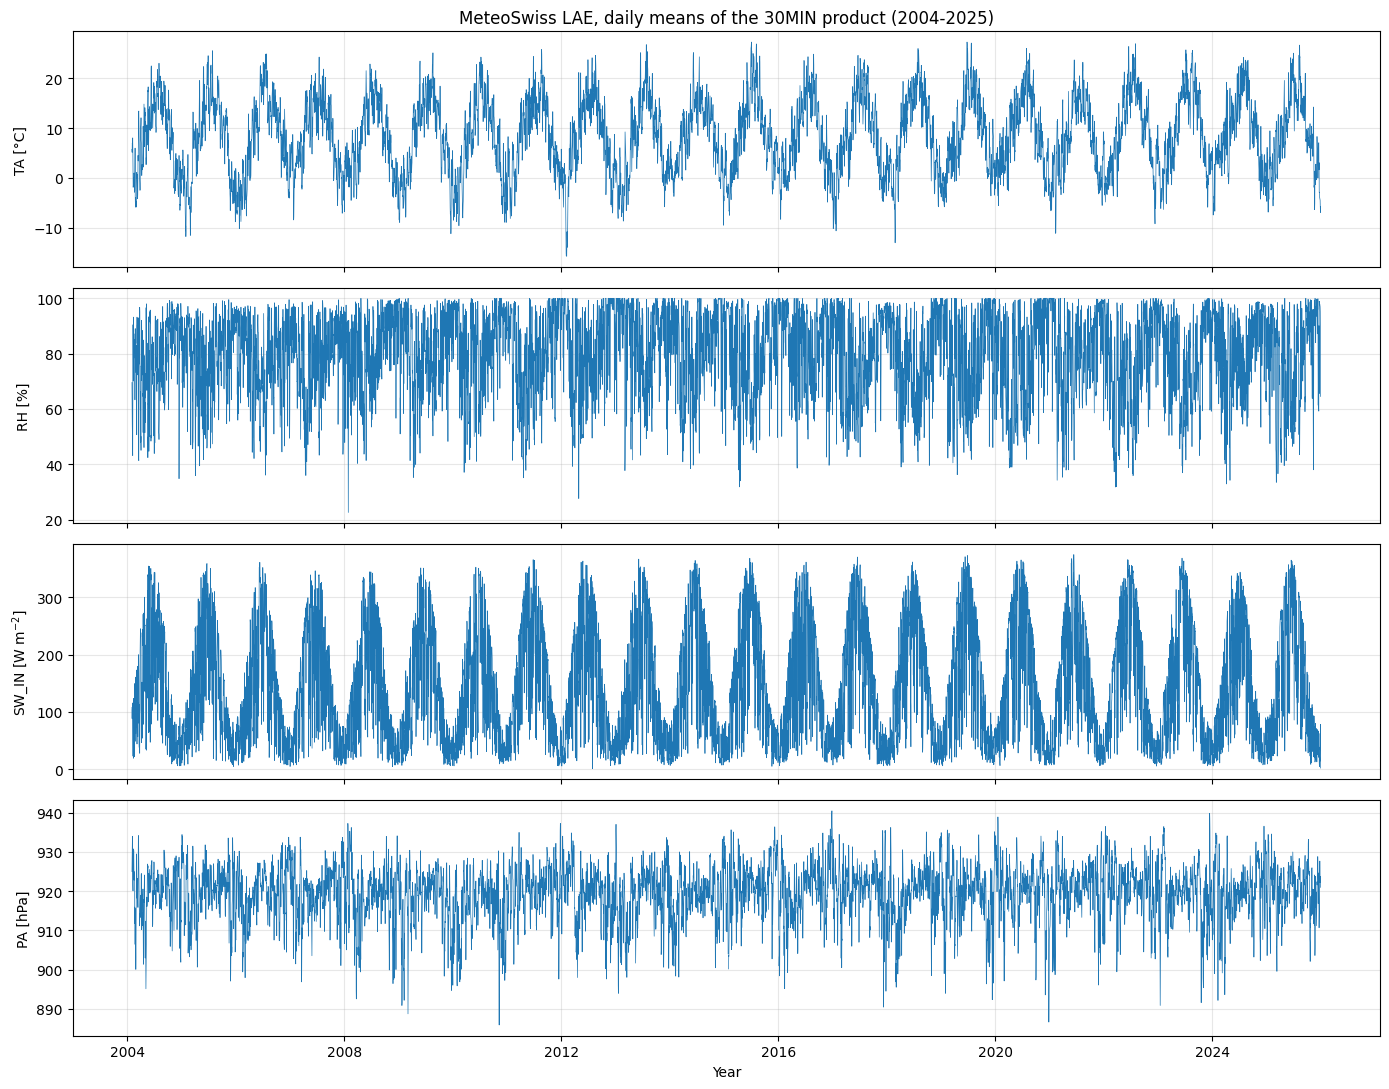

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
for ax, col, lab in [(axes[0], 'TA_LAE_MS', 'TA [°C]'),
                     (axes[1], 'RH_LAE_MS', 'RH [%]'),
                     (axes[2], 'SW_IN_LAE_MS', r'SW_IN [W m$^{-2}$]'),
                     (axes[3], 'PA_LAE_MS', 'PA [hPa]')]:
    _d = lae_out[col].resample('D').mean()
    ax.plot(_d.index, _d, lw=.5, color='tab:blue')
    ax.set_ylabel(lab)
    ax.grid(alpha=.3)
axes[0].set_title(f'MeteoSwiss LAE, daily means of the 30MIN product ({YEARS})')
axes[-1].set_xlabel('Year')
fig.tight_layout()
plt.show()

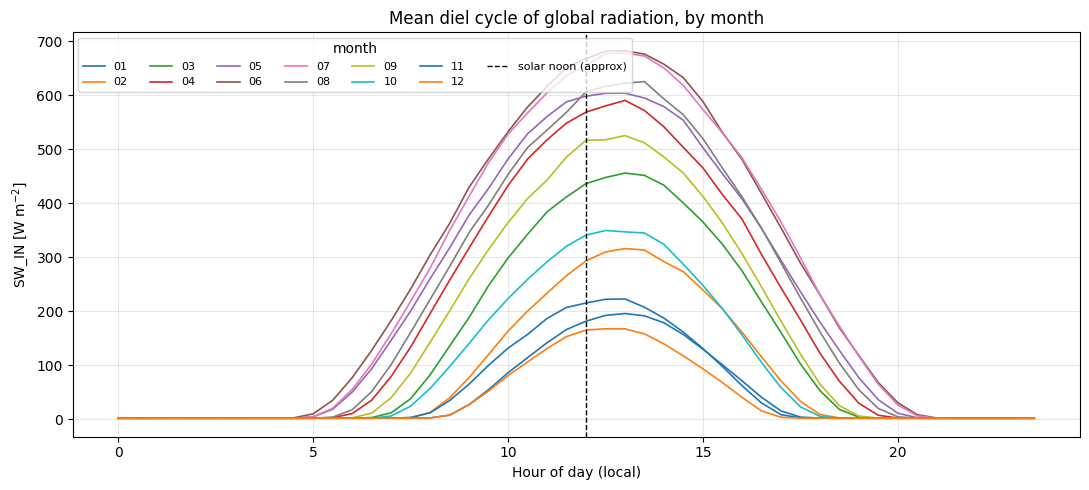

In [15]:
# Mean diel cycle per month: a shape check. A timestamp error would show as a
# radiation curve that is not centred on solar noon.
_sw = lae_out['SW_IN_LAE_MS']
_dc = _sw.groupby([_sw.index.month, _sw.index.hour + _sw.index.minute / 60]).mean().unstack(0)
fig, ax = plt.subplots(figsize=(11, 5))
for _m in _dc.columns:
    ax.plot(_dc.index, _dc[_m], label=f'{_m:02d}', lw=1.2)
ax.axvline(12 + TIMEZONE_OFFSET_TO_UTC_HOURS - 1, color='k', ls='--', lw=1,
           label='solar noon (approx)')
ax.set_xlabel('Hour of day (local)')
ax.set_ylabel(r'SW_IN [W m$^{-2}$]')
ax.set_title('Mean diel cycle of global radiation, by month')
ax.legend(ncol=7, fontsize=8, title='month')
ax.grid(alpha=.3)
fig.tight_layout()
plt.show()

## 💾 Export

In [16]:
outdir = Path(OUTDIR)
outdir.mkdir(parents=True, exist_ok=True)

stem = f'{OUTNAME}_{YEARS}'
written = {}
for fmt in EXPORT_FORMATS:
    path = outdir / f'{stem}.{fmt}'
    if fmt == 'parquet':
        lae_out.to_parquet(path)
    elif fmt == 'csv':
        # index=True keeps the timestamp; NaN stays empty so a gap cannot be
        # mistaken for a real value when the csv is read back elsewhere.
        lae_out.to_csv(path, index=True, na_rep='')
    else:
        raise ValueError(f'unsupported export format: {fmt}')
    written[fmt] = path
    print(f'Wrote {path.name:<45s} ({path.stat().st_size / 1024:>8.0f} KB)')
print(f'\n  in {outdir}')

Wrote MeteoSwiss_LAE_30MIN_2004-2025.parquet        (    8707 KB)


Wrote MeteoSwiss_LAE_30MIN_2004-2025.csv            (   60775 KB)

  in F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\10_REFERENCE


### Read the written file back
Proves the file on disk is what we think it is, rather than trusting the in-memory frame.

In [17]:
back = pd.read_parquet(written['parquet'])
print(f'{len(back):,} records, {back.index[0]} -> {back.index[-1]}')
print(f'columns: {list(back.columns)}')
assert back.index.name == 'TIMESTAMP_END'
assert len(back) == len(lae_out)
assert back['TA_LAE_MS'].notna().sum() == lae_out['TA_LAE_MS'].notna().sum()
print('\nOK: file on disk matches the exported frame.')
back.describe().round(2)

384,241 records, 2004-02-01 01:00:00 -> 2026-01-01 01:00:00
columns: ['TA_LAE_MS', 'RH_LAE_MS', 'TDEW_LAE_MS', 'VP_LAE_MS', 'PA_LAE_MS', 'SW_IN_LAE_MS', 'SW_IN_DIFF_LAE_MS', 'SUNDUR_LAE_MS', 'WS_LAE_MS', 'WS_GUST_LAE_MS', 'WD_LAE_MS', 'N_RECORDS', 'FLAG_INCOMPLETE']

OK: file on disk matches the exported frame.


,TA_LAE_MS,RH_LAE_MS,TDEW_LAE_MS,VP_LAE_MS,PA_LAE_MS,SW_IN_LAE_MS,SW_IN_DIFF_LAE_MS,SUNDUR_LAE_MS,WS_LAE_MS,WS_GUST_LAE_MS,WD_LAE_MS,N_RECORDS,FLAG_INCOMPLETE
count,383970.00,383934.00,383934.00,383934.00,383810.00,384128.00,266844.00,384096.00,381827.00,381827.00,383843.00,384241.00,384241.00
mean,8.33,79.29,4.40,9.11,919.50,141.51,59.41,6.22,4.44,7.39,173.37,3.00,0.00
std,7.88,18.69,6.44,3.90,7.34,231.39,92.23,11.36,2.37,3.93,100.18,0.08,0.03
min,-17.70,3.67,-27.03,0.67,881.70,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2.27,65.70,-0.50,5.90,915.63,2.00,0.67,0.00,2.67,4.50,55.67,3.00,0.00
50%,8.33,83.27,4.57,8.47,920.43,5.33,4.33,0.00,4.20,6.70,203.33,3.00,0.00
75%,14.23,96.77,9.63,11.97,924.27,189.33,86.67,4.00,5.90,9.40,236.36,3.00,0.00
max,32.90,100.00,21.43,25.57,942.53,1155.33,640.33,30.00,17.40,37.60,360.00,3.00,1.00


***
### Note for downstream users
This product is a **reference**, not a screened series. It is exported exactly as MeteoSwiss
published it, aggregated to 30MIN — no outlier removal, no gap-filling, no corrections. Gaps are
real gaps. `FLAG_INCOMPLETE` marks bins built from fewer than three 10-min records.

Two things to remember when comparing against tower data:

- **`PA_LAE_MS` is measured at 845 m**, the tower barometer at roughly 689 m. The two differ by
  the hydrostatic offset of ~156 m of air (order 15 hPa) and must not be compared without
  accounting for it.
- **January 2004 is absent**, and diffuse radiation only begins in 2011.

In [18]:
print(f"Finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Finished: 2026-07-20 21:00:05
